<a href="https://colab.research.google.com/github/suhan-s255/1BM23CS344-SUHAN-S-6THSEM-ML-LAB/blob/main/1BM23CS344_Lab_5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

iris = pd.read_csv("iris (1).csv")
X_iris = iris.iloc[:, :-1]
y_iris = iris.iloc[:, -1]
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)
knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(X_train_i, y_train_i)
y_pred_i = knn_iris.predict(X_test_i)
print("IRIS Dataset Results")
print("Accuracy:", accuracy_score(y_test_i, y_pred_i))
print("Confusion Matrix:\n", confusion_matrix(y_test_i, y_pred_i))
print("Classification Report:\n", classification_report(y_test_i, y_pred_i))

diabetes = pd.read_csv("diabetes.csv")
X_d = diabetes.iloc[:, :-1]
y_d = diabetes.iloc[:, -1]
scaler = StandardScaler()
X_d_scaled = scaler.fit_transform(X_d)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d_scaled, y_d, test_size=0.2, random_state=42, stratify=y_d)
knn_diabetes = KNeighborsClassifier(n_neighbors=7)
knn_diabetes.fit(X_train_d, y_train_d)
y_pred_d = knn_diabetes.predict(X_test_d)
print("\nDiabetes Dataset Results")
print("Accuracy:", accuracy_score(y_test_d, y_pred_d))
print("Confusion Matrix:\n", confusion_matrix(y_test_d, y_pred_d))
print("Classification Report:\n", classification_report(y_test_d, y_pred_d))

IRIS Dataset Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Diabetes Dataset Results
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[84 16]
 [23 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



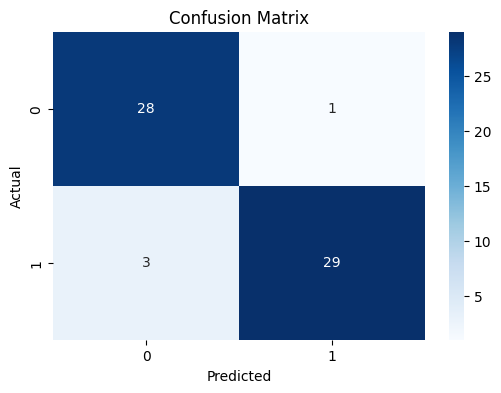

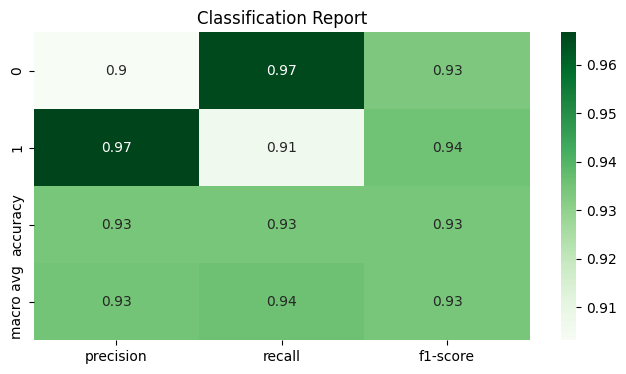

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1)
y = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

scores = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

best_k = k_values[scores.index(max(scores))]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Greens")
plt.title("Classification Report")
plt.show()